In [1]:
import xarray as xr
ds = xr.Dataset(
    data_vars ={
        "temperature":(
            ["time"],
            [30,31,32]
        ),
        "rainfall":(
            ["time"],
            [5,10,0]
        )
    },
    coords={
        "time":["Day1","Day2","Day3"]
    }
)
ds

<xarray.Dataset> Size: 96B
Dimensions:      (time: 3)
Coordinates:
  * time         (time) <U4 48B 'Day1' 'Day2' 'Day3'
Data variables:
    temperature  (time) int64 24B 30 31 32
    rainfall     (time) int64 24B 5 10 0

In [2]:
#find variables
ds.data_vars

Data variables:
    temperature  (time) int64 24B 30 31 32
    rainfall     (time) int64 24B 5 10 0

In [3]:
ds.rainfall

<xarray.DataArray 'rainfall' (time: 3)> Size: 24B
array([ 5, 10,  0])
Coordinates:
  * time     (time) <U4 48B 'Day1' 'Day2' 'Day3'

In [5]:
ds.to_netcdf("my_first_dataset.nc")

In [9]:
ds2 =xr.open_dataset("my_first_dataset.nc")
ds2

<xarray.Dataset> Size: 96B
Dimensions:      (time: 3)
Coordinates:
  * time         (time) <U4 48B 'Day1' 'Day2' 'Day3'
Data variables:
    temperature  (time) int64 24B ...
    rainfall     (time) int64 24B ...

In [10]:
ds2.temperature

<xarray.DataArray 'temperature' (time: 3)> Size: 24B
[3 values with dtype=int64]
Coordinates:
  * time     (time) <U4 48B 'Day1' 'Day2' 'Day3'

In [11]:
ds2.temperature.isel(time=0)

<xarray.DataArray 'temperature' ()> Size: 8B
[1 values with dtype=int64]
Coordinates:
    time     <U4 16B 'Day1'

In [12]:
ds2.temperature.isel(time=2)

<xarray.DataArray 'temperature' ()> Size: 8B
[1 values with dtype=int64]
Coordinates:
    time     <U4 16B 'Day3'

In [13]:
ds2.temperature.mean()

<xarray.DataArray 'temperature' ()> Size: 8B
array(31.)

In [14]:
ds2.temperature.max()

<xarray.DataArray 'temperature' ()> Size: 8B
array(32)

In [15]:
ds2.temperature.min()

<xarray.DataArray 'temperature' ()> Size: 8B
array(30)

In [17]:
ds2["humidity"] = ("time",[70,65,80])
ds2

<xarray.Dataset> Size: 120B
Dimensions:      (time: 3)
Coordinates:
  * time         (time) <U4 48B 'Day1' 'Day2' 'Day3'
Data variables:
    temperature  (time) int64 24B 30 31 32
    rainfall     (time) int64 24B ...
    humidity     (time) int64 24B 70 65 80

In [18]:
ds2.to_netcdf("my_first_dataset_v2.nc")

In [19]:
ds2.data_vars

Data variables:
    temperature  (time) int64 24B 30 31 32
    rainfall     (time) int64 24B ...
    humidity     (time) int64 24B 70 65 80

In [20]:
#creating small climate Map
temp_map = xr.DataArray(
    [[30,31,32,33],
     [29,30,31,32],
     [28,29,30,31]],

     dims = ["lat","lon"],

     coords={
         "lat":[30,31,32],
         "lon":[75,76,77,78]
     }
)

temp_map

<xarray.DataArray (lat: 3, lon: 4)> Size: 96B
array([[30, 31, 32, 33],
       [29, 30, 31, 32],
       [28, 29, 30, 31]])
Coordinates:
  * lat      (lat) int64 24B 30 31 32
  * lon      (lon) int64 32B 75 76 77 78

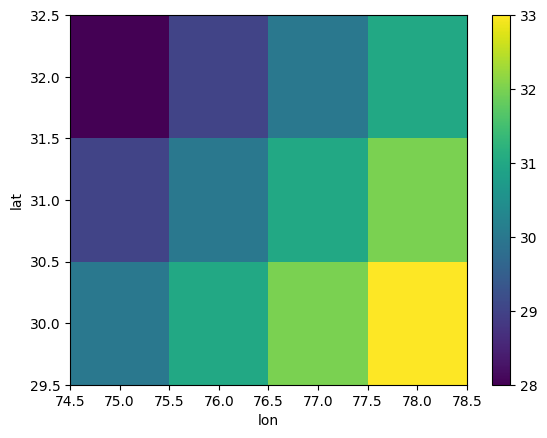

In [21]:
temp_map.plot()

In [22]:
temp_map.sel(lat=31,lon=76)

<xarray.DataArray ()> Size: 8B
array(30)
Coordinates:
    lat      int64 8B 31
    lon      int64 8B 76

In [23]:
temp_map.shape

(3, 4)